# AT&T traffic routing, end to end: network → QUBO → Ising → QAOA → routing

**Challenge (AT&T / QUBIT):** route traffic demands across a capacitated backbone so that
congestion and latency come down without breaking service requirements.

## The pipeline

The problem is NP-hard in the part that matters, so nothing solves it in one shot. It is split
into a classical half that *shapes* the problem and a quantum half that *searches* it.

| step | what happens | where |
| --- | --- | --- |
| 1 | Build the network: real topology, link capacity, delay, cost; demands with bandwidth and priority | `network_instance/att_real.py` |
| 2 | Generate a few candidate routes per demand with Yen's K-shortest-paths, ranked under each competing constraint | `network_instance/yen.py` |
| 3 | Encode "pick one route per demand" as a **QUBO** | `routing_qaoa/qubo.py` |
| 4 | Rewrite the QUBO as an **Ising** Hamiltonian | `network_instance/ising.py` |
| 5 | Minimize it with **QAOA** on Classiq | `routing_qaoa/qaoa.py` |
| 6 | Decode bitstrings back to routes, check capacity, report KPIs | `routing_qaoa/decode.py` |

**Why split it this way.** Choosing a route means choosing among infinitely many walks through a
graph, which no qubit encoding can hold. Step 2 collapses that to a handful of good candidates,
turning a continuous search into a small binary decision: one bit per candidate route. The
quantum layer then only has to answer *which combination*, which is exactly the part that is
combinatorially hard, because every demand's choice changes the cost of every other demand's.

**The cost of that split:** the answer can only ever be as good as the candidate set. Step 2 caps
the quality of everything downstream, which is why it ranks routes under four different
constraints rather than just taking the shortest.

## Setup

Needs the Classiq venv and a Classiq cloud login. If a `ClassiqExpiredTokenError` appears, run
`import classiq; classiq.authenticate()` once in a cell.

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd() / "network_instance"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import att_real as A, ising, qaoa_instance, viz, yen
from routing_qaoa import QuboWeights, brute_force_feasible, decode_bitstring
from routing_qaoa.qubo import build_cost_function, compute_coefficients

pd.set_option("display.width", 200)
TARGET_QUBITS = 28   # one qubit per candidate route

## Step 1 — the network and its constraints

Topology is **AT&T's real North America MPLS backbone**, from the Internet Topology Zoo
(Knight et al., IEEE JSAC 2011), which built it from AT&T's published `Domestic_OC-768_Network.pdf`.
Real PoP codes, real coordinates, real links. We work on a 10-PoP slice.

Each link $e$ carries three attributes the brief asks us to model: capacity $c_e$, delay
$\mathrm{lat}_e$, and operational cost. Delays are **derived from the real geography** —
great-circle distance $\times 1.5$ for fibre detour $\times 5\,\mu s/\mathrm{km}$ for light in
glass — which reproduces reality closely (New York to Los Angeles lands at 30.3 ms).
Capacities, costs and the traffic matrix are synthesized; no carrier publishes those.

Each demand $k$ asks for bandwidth $b_k$ between two PoPs, with a priority $\pi_k$.

In [2]:
instance, current_routing, ctx = qaoa_instance.build(target_qubits=TARGET_QUBITS)
net = ctx["source_instance"]
print(qaoa_instance.summary(instance, current_routing, ctx))

region            : east10_dense
PoPs / links      : 10 / 18  (real AT&T backbone)
demands           : 14
candidate paths   : 28  = qubits
routes past our latency bound (kept: downstream prices latency): 0
demands that lost 1+1 protection downstream: ['T1', 'T2', 'T3', 'T4']


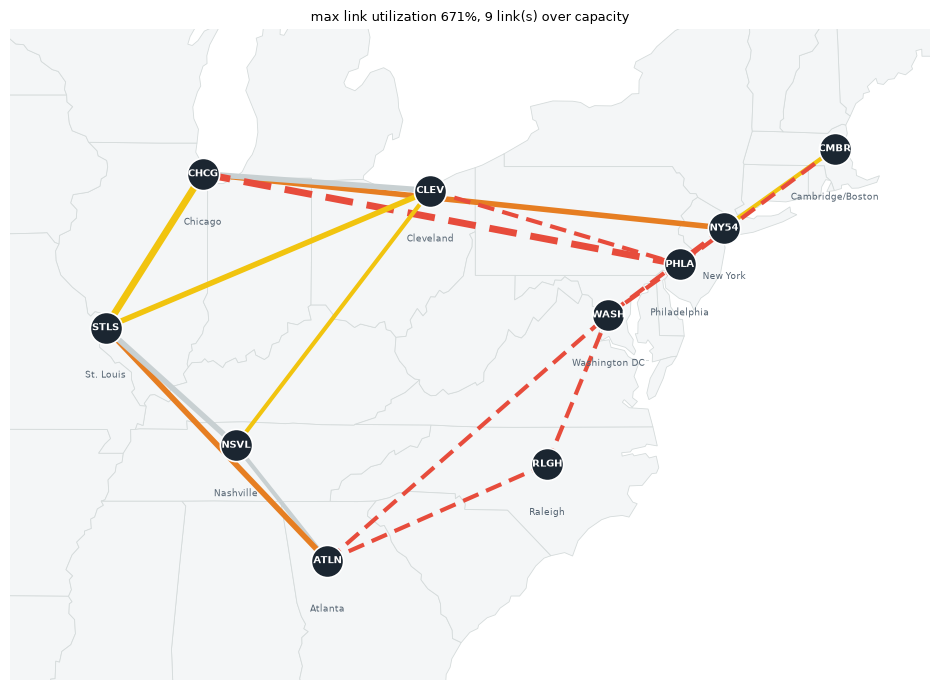

In [3]:
fig, ax = plt.subplots(figsize=(11, 7))
viz.draw_map(net, routing=net.current_routing, ax=ax, annotate=True, font_size=7)
plt.tight_layout(); plt.show()

Red dashed links are **over capacity** under today's routing, where every demand independently
takes its own shortest path the way plain OSPF does. Each of those choices is locally sensible;
together they pile onto the same few links. That is the problem.

In [4]:
viz.demand_table(net)[["demand", "from", "to", "Gbps", "priority", "today's delay", "today's route"]]

,demand,from,to,Gbps,priority,today's delay,today's route
0,T1,NY54,CHCG,108,high,9ms/9ms,NY54-CHCG | NY54-PHLA-CHCG
1,T2,NY54,WASH,72,high,2ms/2ms,NY54-WASH | NY54-PHLA-WASH
2,T3,NY54,PHLA,108,high,1ms/4ms,NY54-PHLA | NY54-WASH-PHLA
3,T4,NY54,ATLN,108,high,9ms/10ms,NY54-WASH-ATLN | NY54-PHLA-WASH-RLGH-ATLN
4,T5,CHCG,WASH,72,medium,10ms,CHCG-PHLA-WASH
5,T6,CHCG,PHLA,135,medium,8ms,CHCG-PHLA
6,T7,CHCG,ATLN,108,medium,9ms,CHCG-STLS-ATLN
7,T8,PHLA,WASH,72,medium,2ms,PHLA-WASH
8,T9,ATLN,WASH,72,medium,6ms,ATLN-WASH
9,T10,ATLN,PHLA,105,low,8ms,ATLN-WASH-PHLA


## Step 2 — candidate routes: 5 best per constraint

Yen's algorithm gives the $K$ shortest **loopless** paths. The first is the shortest path; each
next one is found by walking an accepted path, treating every node as a *spur*, banning the links
that would retrace an existing path from there, and taking the cheapest detour onward.

The three link attributes pull in different directions, so Yen's runs **once per constraint** and
the results are merged:

| metric | constraint it serves |
| --- | --- |
| `delay` | latency: minimize $\sum_e \mathrm{lat}_e$ |
| `cost` | operational cost per Gbps |
| `hops` | resource usage: fewest links touched |
| `spare` | capacity: prefer links with headroom, $w_e = c_e / (c_e - \mathrm{load}_e)$ |

That last one is the *minimum-interference* idea: route where you do least damage to everyone
else's remaining capacity.

In [5]:
demand = net.demands[0]   # the largest demand
print(f"{demand.id}: {A.POP_NAMES[demand.src]} -> {A.POP_NAMES[demand.dst]}, "
      f"{demand.bandwidth}G, priority {demand.priority}")
viz.metric_table(net, demand, k=5)

T1: New York -> Chicago, 108G, priority high


,best by delay,best by cost,best by hops,best by spare
#1,"NY54-CHCG [8.6ms, $3, 1h, +12G]","NY54-CHCG [8.6ms, $3, 1h, +12G]","NY54-CHCG [8.6ms, $3, 1h, +12G]","NY54-CHCG [8.6ms, $3, 1h, +12G]"
#2,"NY54-PHLA-CHCG [9.0ms, $4, 2h, -316G]","NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -316G]","NY54-PHLA-CHCG [9.0ms, $4, 2h, -316G]","NY54-PHLA-CHCG [9.0ms, $4, 2h, -316G]"
#3,"NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -316G]","NY54-PHLA-CHCG [9.0ms, $4, 2h, -316G]","NY54-CMBR-PHLA-CHCG [13.6ms, $5, 3h, -155G]","NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -316G]"
#4,"NY54-WASH-PHLA-CHCG [12.0ms, $5, 3h, -457G]","NY54-CMBR-PHLA-CLEV-CHCG [13.6ms, $4, 4h, -95G]","NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -316G]","NY54-CMBR-PHLA-CHCG [13.6ms, $5, 3h, -155G]"
#5,"NY54-WASH-PHLA-CLEV-CHCG [12.0ms, $4, 4h, -457G]","NY54-WASH-PHLA-CLEV-CHCG [12.0ms, $4, 4h, -457G]","NY54-WASH-PHLA-CHCG [12.0ms, $5, 3h, -457G]","NY54-CMBR-PHLA-CLEV-CHCG [13.6ms, $4, 4h, -95G]"


Read across a row: the metrics **disagree**. The fastest route is routinely one that is already
oversubscribed, while the route with real headroom is slower. There is no single best route to
look up, which is precisely why this is an optimization and not a shortest-path query.

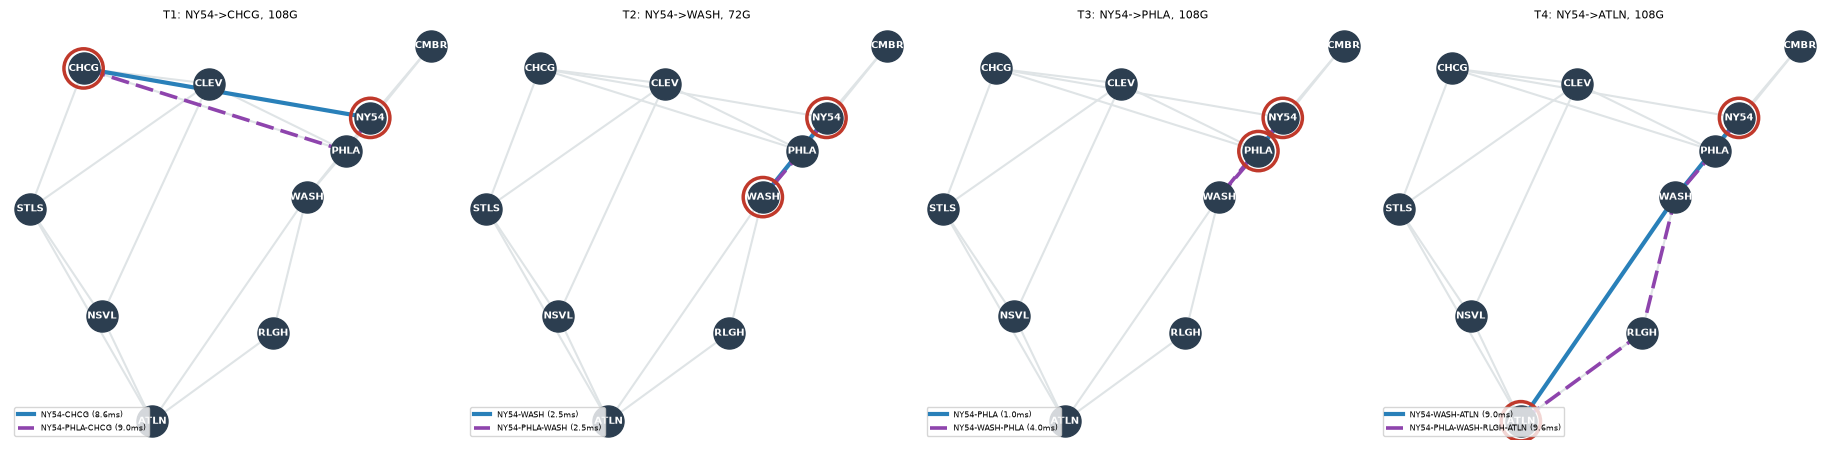

In [6]:
show = net.demands[:4]
fig, axes = plt.subplots(1, len(show), figsize=(4.6 * len(show), 4.6))
for ax, d in zip(axes, show):
    viz.draw_routes(net, ctx["candidates"][d.id], ax=ax,
                    title=f"{d.id}: {d.src}->{d.dst}, {d.bandwidth}G")
plt.tight_layout(); plt.show()

## Step 3 — the QUBO

One binary variable per candidate route: $x_{k,p} = 1$ iff demand $k$ takes its candidate path
$p$. Qubits are indexed flat, $i = \mathrm{offset}_k + p$, so $N = \sum_k |P_k|$.

$$H(x) \;=\; \lambda_{\text{1hot}}\underbrace{\sum_k\Big(\sum_p x_{k,p}-1\Big)^{2}}_{\text{exactly one route per demand}}
\;+\;\underbrace{\sum_{k,p}\tilde L_{k,p}\,x_{k,p}}_{\text{latency}}
\;+\;\lambda_{\text{cong}}\underbrace{\frac{1}{m}\sum_e g(u_e)}_{\text{congestion}}
\;+\;\lambda_{\text{sw}}\underbrace{\sum_k\sum_{p\neq p_{\text{cur}}(k)}x_{k,p}}_{\text{route churn}}$$

- **one-hot** is the only *hard* constraint. Everything else is priced, not forbidden.
- **latency** $\tilde L_{k,p} \propto \pi_k\, b_k \sum_{e\in p}\mathrm{lat}_e$, so a demand's
  latency counts in proportion to how much traffic and how much priority rides on it.
- **congestion** uses link utilization $u_e=\sum_{(k,p)\ni e} (b_k/c_e)\,x_{k,p}$ with
  $g(u)=u^2$, or a quadratic fitted to the piecewise-linear **Fortz–Thorup** link cost
  (INFOCOM 2000, the AT&T Labs traffic-engineering paper).
- **churn** penalizes moving a demand off the route it runs today.

Note $u_e$ is *linear* in $x$, so $g(u_e)=u_e^2$ makes the objective quadratic — degree 2 is
exactly what "QUBO" allows, and what a QAOA phase layer can implement.

In [7]:
weights = QuboWeights(lambda_onehot=4.0, lambda_cong=1.0, lambda_switch=0.2)
coeffs = compute_coefficients(instance, weights, current_routing)
cost = build_cost_function(coeffs)

print(f"qubits N            : {instance.num_qubits}")
print(f"one-hot groups      : {len(coeffs.onehot_groups)}  (one per demand)")
print(f"links with traffic  : {len(coeffs.link_terms)}  (each contributes a u_e^2 term)")
print(f"congestion prefactor: {coeffs.cong_scale:.4f}")

qubits N            : 28
one-hot groups      : 14  (one per demand)
links with traffic  : 26  (each contributes a u_e^2 term)
congestion prefactor: 0.0385


## Step 4 — QUBO to Ising

QAOA is stated over spins, so rewrite $x_i\in\{0,1\}$ as $z_i\in\{-1,+1\}$. Expanding the squares
and using idempotence $x_i^2 = x_i$ puts the QUBO in the canonical form

$$H(x) = c + \sum_i L_i x_i + \sum_{i<j} Q_{ij}\,x_i x_j$$

then the substitution

$$x_i = \frac{1-z_i}{2}$$

collects into the Ising Hamiltonian

$$H(z) = \text{offset} + \sum_i h_i z_i + \sum_{i<j} J_{ij} z_i z_j,
\qquad
h_i = -\frac{L_i}{2} - \frac14\sum_{j\neq i} Q_{ij},
\qquad
J_{ij} = \frac{Q_{ij}}{4}$$

On hardware $z_i \mapsto \hat\sigma^z_i$, so $h_i$ is a local field on qubit $i$ and $J_{ij}$ a
two-qubit coupling. **$J_{ij}\neq 0$ exactly when routes $i$ and $j$ share a link**, or belong to
the same demand — the coupling graph *is* the interference structure of the network.

In [8]:
Q, L, const = ising.qubo_matrix(coeffs, instance.num_qubits)
h, J, offset = ising.to_ising(Q, L, const)

check = ising.verify(coeffs, instance.num_qubits)
print(f"local fields h_i   : {check['num_fields']}")
print(f"couplings J_ij != 0: {check['num_couplings']}  of {instance.num_qubits*(instance.num_qubits-1)//2} possible")
print(f"max |H_ising - H_routing_qaoa| over 200 random assignments: {check['max_error_ising_vs_routing_qaoa']:.2e}")

local fields h_i   : 28
couplings J_ij != 0: 75  of 378 possible
max |H_ising - H_routing_qaoa| over 200 random assignments: 7.11e-15


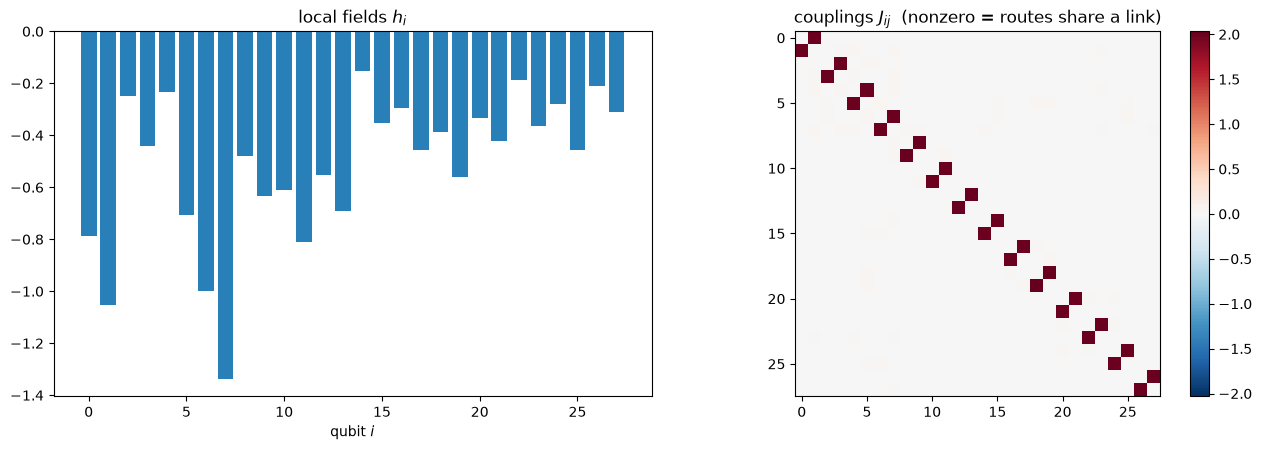

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].bar(range(len(h)), h, color="#2980b9")
axes[0].set_title("local fields $h_i$"); axes[0].set_xlabel("qubit $i$")
m = np.triu(J, 1); m = m + m.T
im = axes[1].imshow(m, cmap="RdBu_r", vmin=-np.abs(m).max(), vmax=np.abs(m).max())
axes[1].set_title("couplings $J_{ij}$  (nonzero = routes share a link)")
plt.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()

## Step 5 — QAOA

Prepare the uniform superposition $|+\rangle^{\otimes N}$ over every assignment, then alternate
a **phase** layer built from the cost and a **mixer** layer, $p$ times:

$$|\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=1}^{p}
e^{-i\beta_l B}\,e^{-i\gamma_l H}\;|+\rangle^{\otimes N},
\qquad B=\sum_{i} \hat\sigma^x_i$$

$e^{-i\gamma H}$ stamps each basis state with a phase proportional to its cost; the mixer lets
amplitude flow between states. A classical optimizer (COBYLA) tunes the $2p$ angles to minimize
$\langle H\rangle$, concentrating measurement probability on low-cost assignments.

Classiq builds the phase layer straight from the cost polynomial via `phase()`, so the same
expression defines the circuit and scores sampled bitstrings.

### What is actually being minimized

Two losses, one nested in the other, and they are worth keeping apart:

**1. The problem loss** $H(x)$ — the QUBO above, scoring one routing. In code that is
`qubo.build_cost_function`, four lines summing the latency, congestion and one-hot terms. It is
*dual-use*: handed a `QArray` it builds the quantum phase gadget, handed a list of ints it scores
a sampled bitstring. One expression both ways, so the circuit and the classical scoring cannot
drift apart.

**2. The variational loss** — what COBYLA actually minimizes:

$$F(\boldsymbol\gamma,\boldsymbol\beta)=\langle\psi(\boldsymbol\gamma,\boldsymbol\beta)|H|\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle$$

estimated by sampling, via `ExecutionSession.estimate_cost`. $H$ never changes; only the $2p$
angles do. The quantum computer therefore minimizes nothing on its own — it prepares a
distribution, and the classical optimizer reshapes it until low-cost bitstrings dominate.

**This runs on Classiq's cloud *simulator*, not a QPU.** `ExecutionSession` is built with no
backend preference, so it takes the default simulator, and that is exactly where the 28-qubit
ceiling comes from: state-vector simulation carries $2^N$ amplitudes, about 268 million complex
numbers at $N=28$. Nothing here has touched quantum hardware.

**Runtime:** about 25 s per optimizer iteration at 28 qubits, so the settings below take roughly
5 minutes. Raise `max_iterations` for better results.

In [10]:
from routing_qaoa.qaoa import QaoaConfig, run_qaoa

config = QaoaConfig(num_layers=2, num_shots=1024, max_iterations=12, random_seed=42)
t0 = time.time()
result = run_qaoa(instance, weights, config, current_routing=current_routing)
print(f"QAOA finished in {time.time()-t0:.0f}s over {instance.num_qubits} qubits")
print(f"optimized angles (gamma, beta): {np.round(result.optimal_params, 3)}")

QAOA finished in 364s over 28 qubits
optimized angles (gamma, beta): [ 0.437  3.799  3.585 -0.265]


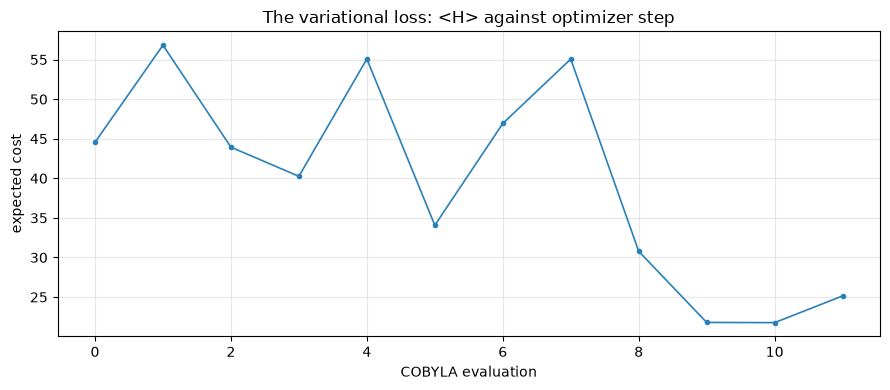

start 44.5583  ->  best 21.7675   over 12 evaluations


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(result.objective_values, marker="o", ms=3, lw=1.2, color="#2980b9")
ax.set_xlabel("COBYLA evaluation")
ax.set_ylabel("expected cost")
ax.set_title("The variational loss: <H> against optimizer step")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"start {result.objective_values[0]:.4f}  ->  best {min(result.objective_values):.4f}"
      f"   over {len(result.objective_values)} evaluations")

## Step 6 — results and decoding

A sampled bitstring is only a valid routing if it is **one-hot per demand**: exactly one route
chosen for each. The penalty term pushes towards that but does not guarantee it, so decoding
filters for feasibility first, then reconstructs the routes and recomputes link loads.

In [12]:
from routing_qaoa import best_feasible_solution, feasible_probability, top_solutions

p_feasible = feasible_probability(result.samples, instance, config.num_shots)
print(f"probability mass on one-hot-feasible bitstrings: {p_feasible:.1%}")
top_solutions(result.samples, instance, coeffs, config.num_shots, k=5)

probability mass on one-hot-feasible bitstrings: 6.1%


,probability,bits,path[T1],path[T2],path[T3],path[T4],path[T5],path[T6],path[T7],path[T8],...,path[T11],path[T12],path[T13],path[T14],feasible,cap_violations,max_util,weighted_latency,phi_star,cost
0,0.000977,1100101010110101000101000000,NaN,NaN,0,0.0,0.0,NaN,1.0,1.0,...,1,NaN,NaN,NaN,False,8,2.2500,4779.4,540.681478,40.789044
1,0.000977,0010101001110110101101000000,NaN,0.0,0,0.0,1.0,NaN,1.0,0.0,...,1,NaN,NaN,NaN,False,6,2.2500,4380.4,548.505788,34.912459
2,0.000977,1010010000011000000010101001,0.0,0.0,1,NaN,NaN,1.0,0.0,NaN,...,0,0.0,0.0,1.0,False,6,2.7500,5918.4,989.813585,27.648263
3,0.000977,0110010000111101000010101001,1.0,0.0,1,NaN,NaN,NaN,NaN,1.0,...,0,0.0,0.0,1.0,False,5,3.1500,4194.0,1093.048178,35.267154
4,0.000977,1001010111101001100010101001,0.0,1.0,1,1.0,NaN,0.0,0.0,1.0,...,0,0.0,0.0,1.0,False,8,2.8125,7675.2,1668.158836,21.439545


Most sampled bitstrings are **not** valid routings: with 14 independent one-hot groups, the
uniform superposition puts almost no weight on feasible states, and the penalty term has to
concentrate it. The feasible fraction above is the honest measure of how well that worked at this
circuit depth. Postselecting on feasibility is what turns the sample into an answer.

In [13]:
solution, solution_prob = best_feasible_solution(result.samples, instance, coeffs, config.num_shots)
print(f"best feasible bitstring was sampled with probability {solution_prob:.2%}")
reference = brute_force_feasible(instance, weights, current_routing=current_routing)


def solution_row(label, assignment):
    bits = [0] * instance.num_qubits
    for k, d in enumerate(instance.demands):
        bits[instance.flat_index(k, assignment[d.name])] = 1
    s = decode_bitstring(bits, instance, coeffs)
    return {
        "solution": label,
        "cost": round(s.cost, 4),
        "max utilization": f"{s.max_utilization:.0%}",
        "links over capacity": s.capacity_violations,
        "weighted latency": round(s.weighted_latency, 1),
        "Phi*": round(s.phi_star, 3),
    }


pd.DataFrame([
    solution_row("today's routing", current_routing),
    solution_row("QAOA best feasible", solution.chosen),
    solution_row("brute-force optimum", reference.best_assignment),
])

best feasible bitstring was sampled with probability 0.10%


,solution,cost,max utilization,links over capacity,weighted latency,Phi*
0,today's routing,10.3024,281%,9,8666.4,1414.73
1,QAOA best feasible,10.7522,281%,11,8729.4,1309.99
2,brute-force optimum,10.3024,281%,9,8666.4,1414.73


$\Phi^\*$ is Fortz & Thorup's normalized congestion cost: 1.0 means every link is loaded as
cheaply as it could possibly be, and it climbs steeply once links pass about 2/3 utilization.
It is the single number their paper uses to compare routings, so it is the fair yardstick here.

## Step 6 — decoding back to routes

In [14]:
changed = [n for n, p in solution.chosen.items() if p != current_routing[n]]
gap = (solution.cost - reference.best_cost) / abs(reference.best_cost)
print(f"gap to brute-force optimum : {gap:+.2%}")
print(f"demands matching optimum   : {sum(1 for n, p in solution.chosen.items() if reference.best_assignment[n] == p)}/{len(instance.demands)}")
print(f"demands rerouted vs today  : {changed or 'none'}")
print()
for k, d in enumerate(instance.demands):
    p = solution.chosen[d.name]
    links = instance.paths_of(k)[p].links
    route = "-".join([links[0][0]] + [b for _, b in links])
    flag = "   <-- moved" if d.name in changed else ""
    print(f"  {d.name:4s} {d.source}->{d.target}  {d.bandwidth:5.0f}G  pi={d.priority:.0f}  {route}{flag}")

gap to brute-force optimum : +4.37%
demands matching optimum   : 12/14
demands rerouted vs today  : ['T10', 'T12']

  T1   NY54->CHCG    108G  pi=3  NY54-CHCG
  T2   NY54->WASH     72G  pi=3  NY54-WASH
  T3   NY54->PHLA    108G  pi=3  NY54-PHLA
  T4   NY54->ATLN    108G  pi=3  NY54-WASH-ATLN
  T5   CHCG->WASH     72G  pi=2  CHCG-PHLA-WASH
  T6   CHCG->PHLA    135G  pi=2  CHCG-PHLA
  T7   CHCG->ATLN    108G  pi=2  CHCG-STLS-ATLN
  T8   PHLA->WASH     72G  pi=2  PHLA-WASH
  T9   ATLN->WASH     72G  pi=2  ATLN-WASH
  T10  ATLN->PHLA    105G  pi=1  ATLN-RLGH-WASH-PHLA   <-- moved
  T11  CMBR->STLS     65G  pi=1  CMBR-PHLA-CLEV-STLS
  T12  CMBR->CLEV     55G  pi=1  CMBR-NY54-PHLA-CLEV   <-- moved
  T13  CMBR->NSVL     55G  pi=1  CMBR-PHLA-CLEV-NSVL
  T14  CMBR->RLGH     45G  pi=1  CMBR-NY54-WASH-RLGH


In [15]:
worst = sorted(solution.link_kpis, key=lambda l: -l.utilization)[:8]
pd.DataFrame([
    {"link": f"{l.link[0]}->{l.link[1]}", "load (Gbps)": l.load,
     "utilization": f"{l.utilization:.0%}", "over capacity": l.over_capacity}
    for l in worst
])

,link,load (Gbps),utilization,over capacity
0,NY54->WASH,225.0,281%,True
1,PHLA->CLEV,175.0,219%,True
2,NY54->PHLA,163.0,204%,True
3,PHLA->WASH,144.0,180%,True
4,CMBR->PHLA,120.0,150%,True
5,WASH->ATLN,108.0,135%,True
6,ATLN->RLGH,105.0,131%,True
7,RLGH->WASH,105.0,131%,True


## How the two halves scale

Does any of this get better than classical as the problem grows?

Exact enumeration searches $\prod_k |P_k| = n^D$ one-hot assignments for $D$ demands with $n$
routes each, which is exponential and arrives fast. The quantum encoding needs one qubit per
candidate route, $N = nD$, which is linear. The couplings $J_{ij}$ grow with how many route pairs
share a link, that is the network's interference structure rather than $2^D$.

Measured on real synthesis, not asserted:

In [16]:
import scaling

rows = scaling.sweep([4, 12, 20, 28])
pd.DataFrame([{
    "qubits": r["qubits"],
    "demands": r["demands"],
    "classical assignments": r["combinations"],
    "classical seconds": round(r["seconds"], 4),
    "couplings": r["route_pair_couplings"],
    "2-qubit gates": (r["gate_counts"] or {}).get("cx"),
} for r in rows])

,qubits,demands,classical assignments,classical seconds,couplings,2-qubit gates
0,4,2,4,0.0001,2,8
1,12,6,64,0.0011,14,56
2,20,10,1024,0.0216,40,144
3,28,14,16384,0.4594,89,300


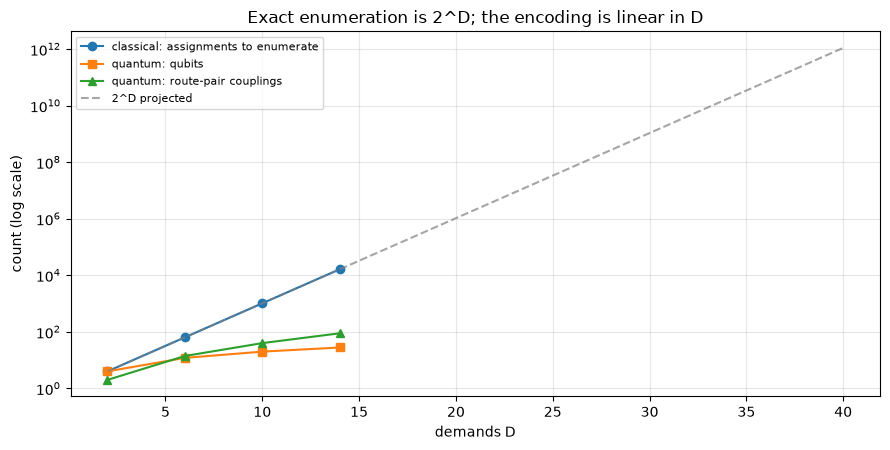

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.6))
d = [r["demands"] for r in rows]
ax.semilogy(d, [r["combinations"] for r in rows], "o-", label="classical: assignments to enumerate")
ax.semilogy(d, [r["qubits"] for r in rows], "s-", label="quantum: qubits")
ax.semilogy(d, [r["route_pair_couplings"] for r in rows], "^-", label="quantum: route-pair couplings")
projected = list(range(2, 41))
ax.semilogy(projected, [2 ** n for n in projected], "--", color="grey", alpha=0.7,
            label="2^D projected")
ax.set_xlabel("demands D")
ax.set_ylabel("count (log scale)")
ax.set_title("Exact enumeration is 2^D; the encoding is linear in D")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**This is not a speedup claim.** At every size measured, exact enumeration is both faster *and*
better than QAOA, which lands about 19% above the optimum. The favourable scaling is in what the
circuit **costs to represent**, not in time-to-solution. And the fair classical opponent at large
$D$ is not brute force at all, it is a heuristic like Fortz-Thorup local search, which is also
polynomial and today wins outright.

The narrow defensible claim: exact enumeration dies at $2^D$, so 100 demands is $2^{100}$ and
permanently out of reach, while encoding that same problem takes 200 qubits. Whether a shallow
QAOA returns anything useful at that width is unproven, and this notebook does not prove it.

## Where this lands

The classical half builds a real problem: real AT&T topology, geography-derived delays, and a
candidate set ranked under four competing constraints. The quantum half searches the resulting
28-qubit space.

Two honest caveats. QAOA at this depth does not beat the classical brute force here — with 28
qubits the whole feasible space is only $2^{14}$ one-hot assignments, which a laptop enumerates
instantly. The argument for the quantum route is asymptotic, not present-day. And 1+1 protection,
which the generator supports, cannot be expressed downstream because the model selects exactly one
route per demand; `export.protected_demands()` reports which demands lose that guarantee.